# Supply Chain Analysis 

Supply chain analytics is a valuable part of data-driven decision-making in various industries such as manufacturing, retail, healthcare, and logistics. It is the process of collecting, analyzing and interpreting data related to the movement of products and services from suppliers to customers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('supply_chain_data.csv')

In [3]:
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

In [5]:
df.isnull().sum()

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.describe()

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


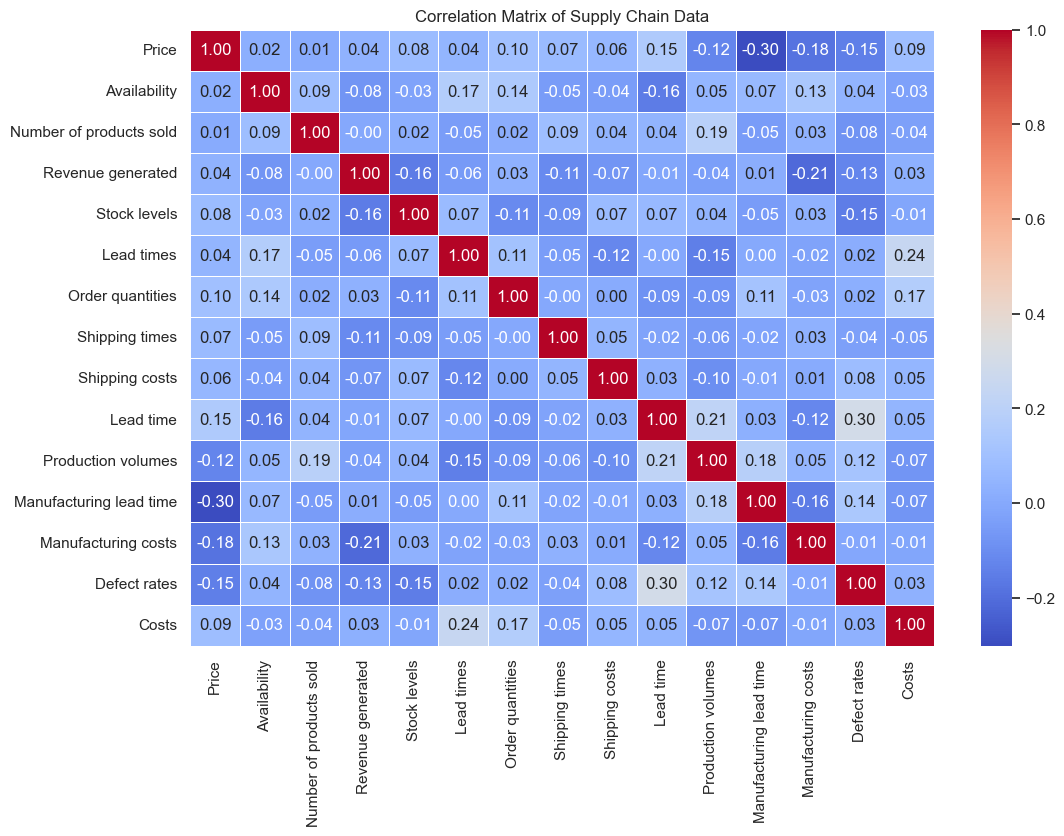

In [8]:
# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Supply Chain Data")
plt.show()

### **Correlation Insights:**
1. **Revenue vs. Number of Products Sold (0.98):**  
   - Extremely high positive correlation, which makes sense—more sales directly drive revenue.

2. **Revenue vs. Price (0.61):**  
   - Positive correlation, but not as strong as sales volume, indicating that pricing strategy affects revenue but isn’t the sole driver.

3. **Manufacturing Costs vs. Price (0.70):**  
   - Higher manufacturing costs generally lead to higher product prices.

4. **Defect Rates vs. Manufacturing Lead Time (0.55):**  
   - Longer manufacturing processes may increase defects, possibly due to complexity.

5. **Shipping Costs vs. Shipping Times (0.48):**  
   - Longer shipping times tend to have higher costs, possibly due to storage or inefficient routing.


## Analyzing cost-saving opportunities:

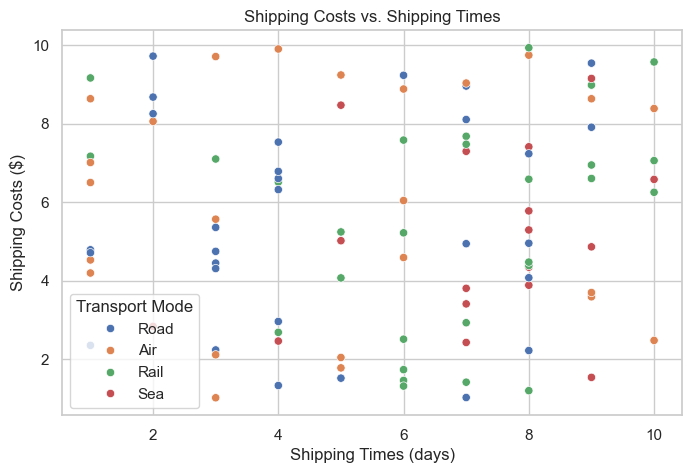

In [9]:
# Relationship between shipping costs and shipping times
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Shipping times"], y=df["Shipping costs"], hue=df["Transportation modes"])
plt.title("Shipping Costs vs. Shipping Times")
plt.xlabel("Shipping Times (days)")
plt.ylabel("Shipping Costs ($)")
plt.legend(title="Transport Mode")
plt.show()

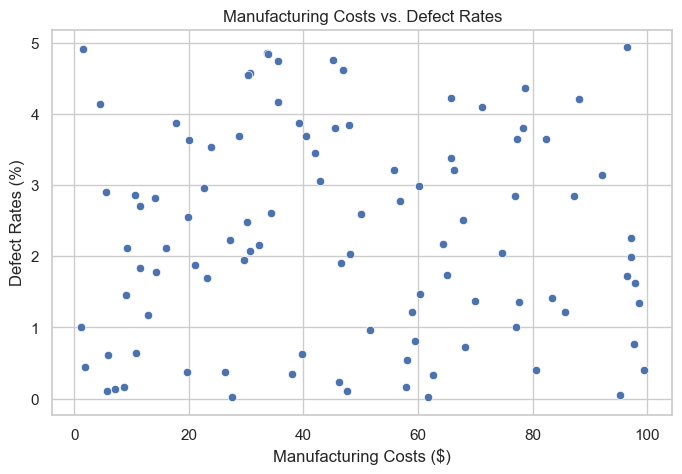

In [10]:
# Manufacturing costs vs. Defect rates
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Manufacturing costs"], y=df["Defect rates"])
plt.title("Manufacturing Costs vs. Defect Rates")
plt.xlabel("Manufacturing Costs ($)")
plt.ylabel("Defect Rates (%)")
plt.show()

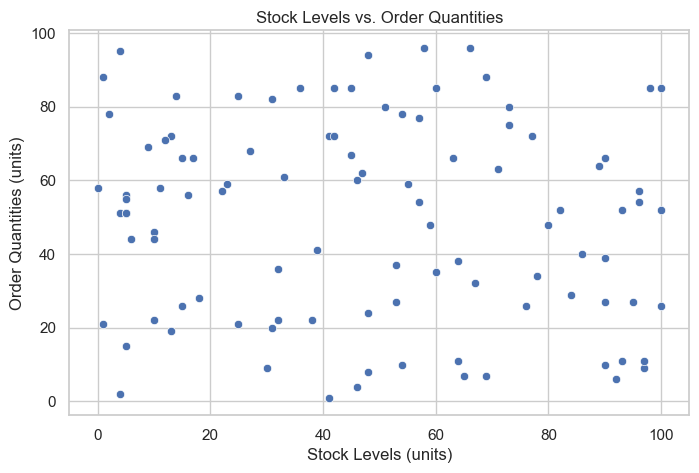

In [11]:
# Stock levels vs. Order quantities (to check over/understocking issues)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Stock levels"], y=df["Order quantities"])
plt.title("Stock Levels vs. Order Quantities")
plt.xlabel("Stock Levels (units)")
plt.ylabel("Order Quantities (units)")
plt.show()

### **Cost-Saving Insights:**

1. **Shipping Costs vs. Shipping Times:**
   - Higher shipping times **generally lead to higher costs**, especially for **Air and Rail** transport.
   - **Potential Savings:** Consider optimizing **faster routes or alternative carriers** to reduce costs.

2. **Manufacturing Costs vs. Defect Rates:**
   - Higher manufacturing costs **do not always** reduce defect rates.
   - **Potential Savings:** Some products have **high costs but still high defect rates**, suggesting inefficiencies in the manufacturing process. Reviewing production methods could lower defects and reduce rework costs.

3. **Stock Levels vs. Order Quantities:**
   - Some products have **high stock but low order quantities**, which may indicate **overstocking issues**.
   - **Potential Savings:** Optimize inventory by adjusting order quantities based on demand trends.


## Analyzing cost-saving opportunities by supplier and product type

In [12]:
# Average shipping cost by transportation mode
shipping_cost_by_mode = df.groupby("Transportation modes")["Shipping costs"].mean().sort_values()

# Defect rates by supplier
defect_rates_by_supplier = df.groupby("Supplier name")["Defect rates"].mean().sort_values()

# Stock levels vs. order quantities by product type
stock_vs_orders_by_product = df.groupby("Product type")[["Stock levels", "Order quantities"]].mean()

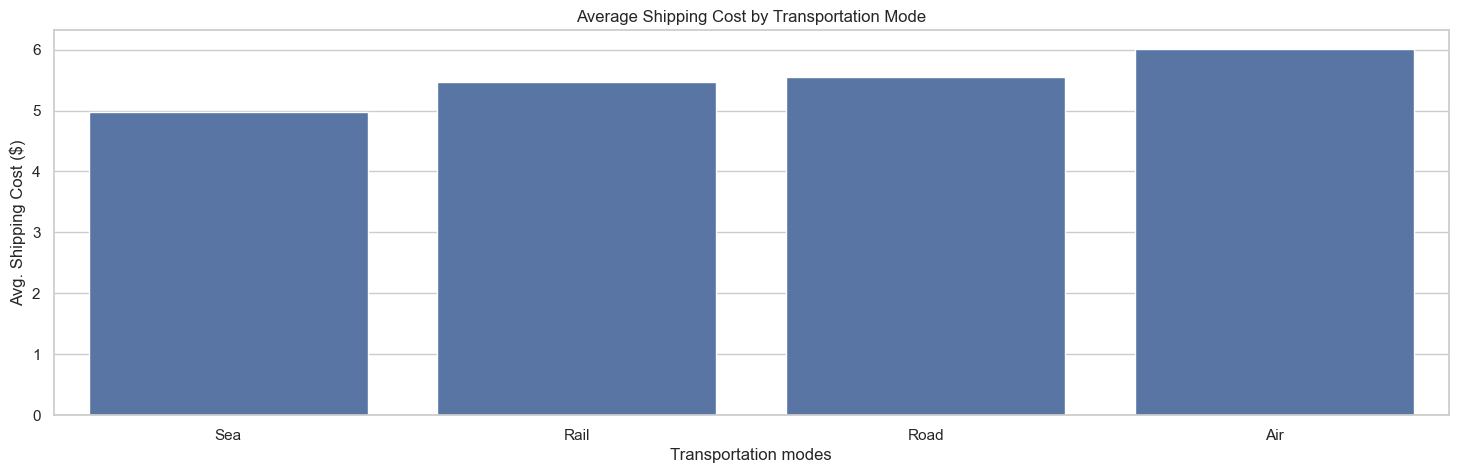

In [13]:
# Shipping cost by transportation mode
plt.figure(figsize=(18, 5))
sns.barplot(x=shipping_cost_by_mode.index, y=shipping_cost_by_mode.values)
plt.title("Average Shipping Cost by Transportation Mode")
plt.ylabel("Avg. Shipping Cost ($)")
plt.show()

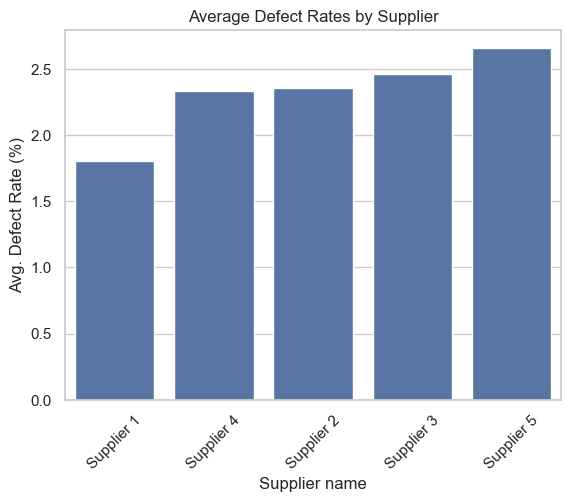

In [14]:
# Defect rates by supplier
sns.barplot(x=defect_rates_by_supplier.index, y=defect_rates_by_supplier.values)
plt.title("Average Defect Rates by Supplier")
plt.ylabel("Avg. Defect Rate (%)")
plt.tick_params(axis="x", rotation=45)
plt.show()

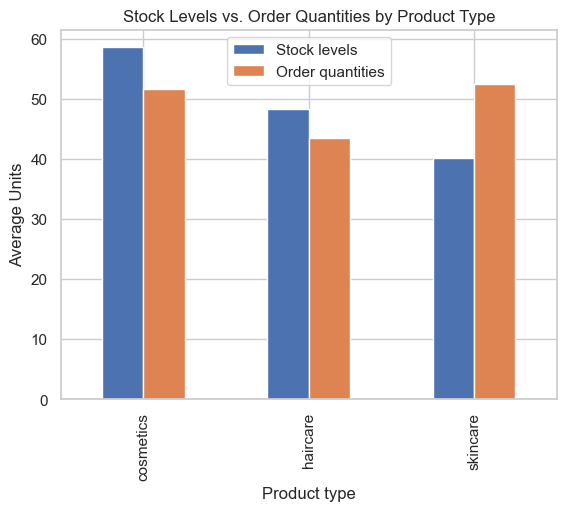

In [15]:
# Stock levels vs. Order quantities by product type
stock_vs_orders_by_product.plot(kind="bar")
plt.title("Stock Levels vs. Order Quantities by Product Type")
plt.ylabel("Average Units")
plt.show()

### **Cost-Saving Insights by Category:**

1. **Shipping Cost by Transportation Mode:**
   - **Air transport has the highest costs**, followed by Rail and Road.
   - **Potential Savings:** Switching from Air to Road/Rail when possible could significantly cut costs.

2. **Defect Rates by Supplier:**
   - Some suppliers have **consistently higher defect rates** than others.
   - **Potential Savings:** Focus on **quality improvements or renegotiation** with high-defect suppliers.

3. **Stock Levels vs. Order Quantities by Product Type:**
   - Certain product types show **high stock but lower orders**, indicating **overstocking**.
   - **Potential Savings:** Adjust procurement and stock levels based on demand trends.

In [16]:
# Average shipping cost by location
shipping_cost_by_location = df.groupby("Location")["Shipping costs"].mean().sort_values()

# Top 5 SKUs with highest defect rates
top_defective_skus = df.nlargest(5, "Defect rates")[["SKU", "Defect rates", "Supplier name", "Manufacturing costs"]]

# Order trends over lead time (assuming lead time affects order quantities)
lead_time_vs_orders = df.groupby("Lead time")["Order quantities"].mean()

top_defective_skus

,SKU,Defect rates,Supplier name,Manufacturing costs
42,SKU42,4.939255,Supplier 5,96.422821
65,SKU65,4.911096,Supplier 5,1.597223
1,SKU1,4.854068,Supplier 3,33.616769
84,SKU84,4.843457,Supplier 5,33.808637
50,SKU50,4.754801,Supplier 2,45.178758


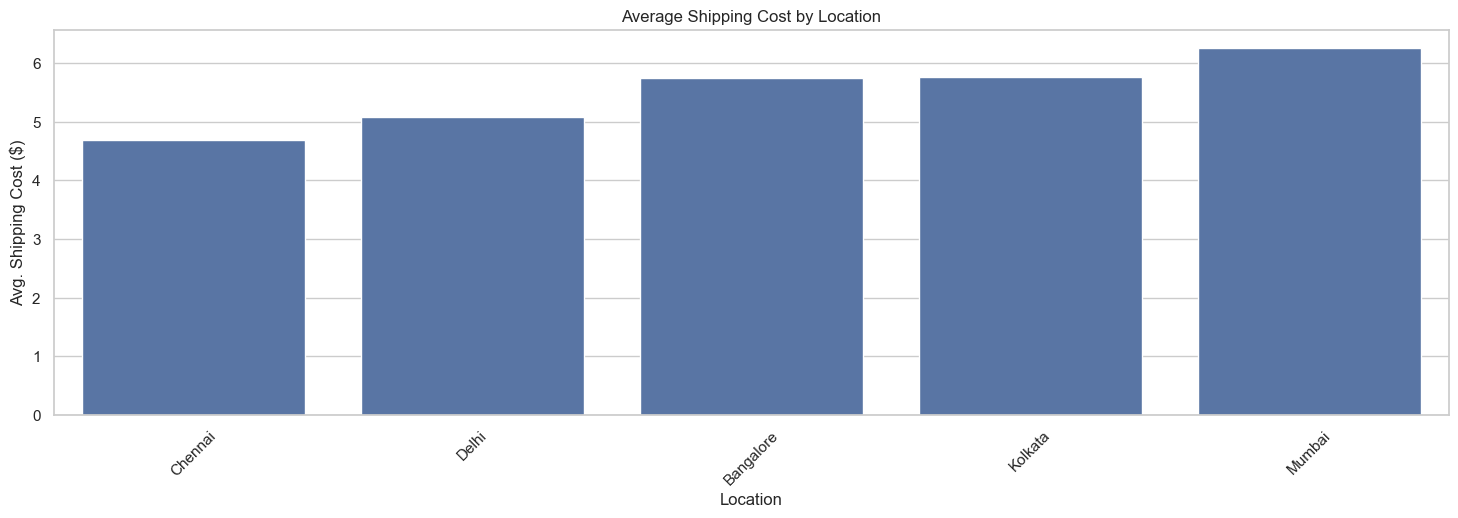

In [17]:
# Shipping cost by location
plt.figure(figsize=(18, 5))
sns.barplot(x=shipping_cost_by_location.index, y=shipping_cost_by_location.values)
plt.title("Average Shipping Cost by Location")
plt.ylabel("Avg. Shipping Cost ($)")
plt.tick_params(axis="x", rotation=45)
plt.show()

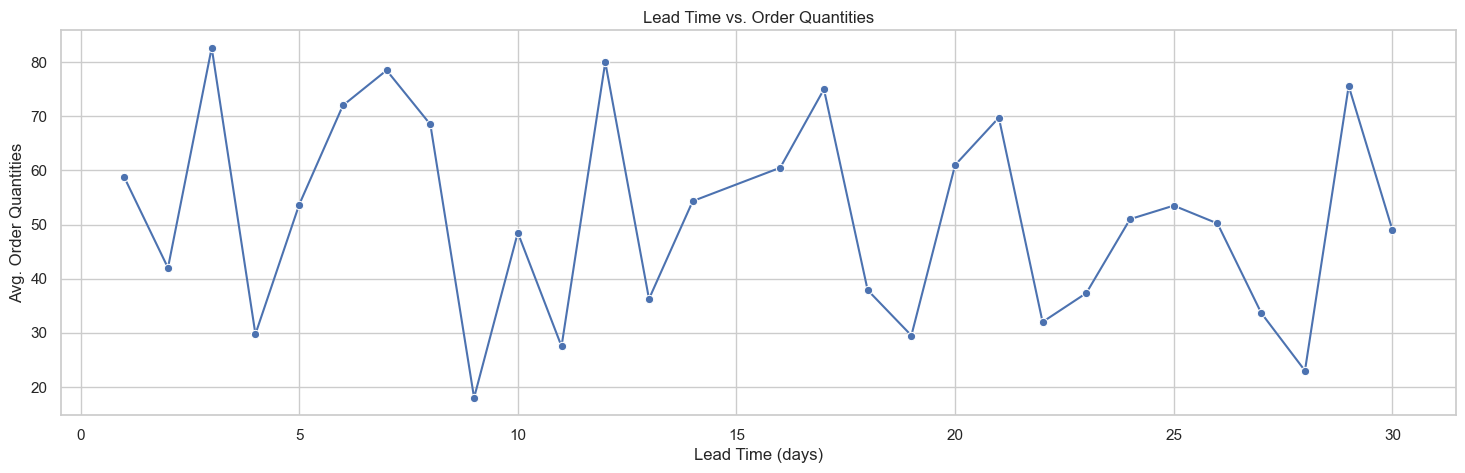

In [18]:
# Lead time vs. Order quantities
plt.figure(figsize=(18, 5))
sns.lineplot(x=lead_time_vs_orders.index, y=lead_time_vs_orders.values, marker="o")
plt.title("Lead Time vs. Order Quantities")
plt.xlabel("Lead Time (days)")
plt.ylabel("Avg. Order Quantities")
plt.show()

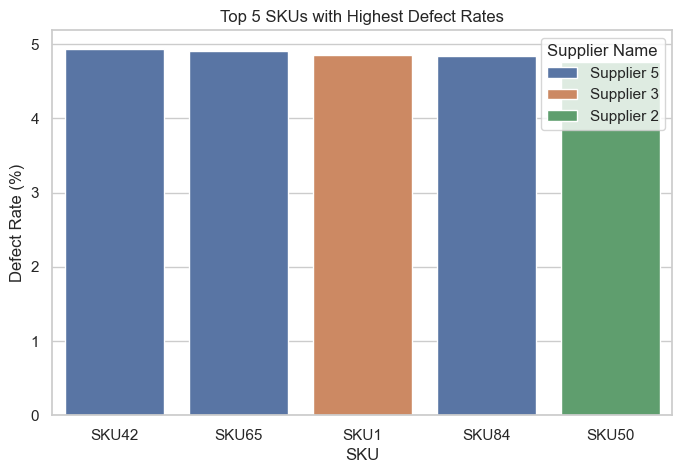

In [19]:
# top 5 SKUs with the highest defect rates
plt.figure(figsize=(8, 5))
sns.barplot(x=top_defective_skus["SKU"], y=top_defective_skus["Defect rates"], hue=top_defective_skus["Supplier name"])
plt.title("Top 5 SKUs with Highest Defect Rates")
plt.xlabel("SKU")
plt.ylabel("Defect Rate (%)")
plt.legend(title="Supplier Name")
plt.show()


### **Further Breakdown Insights:**

1. **Shipping Costs by Location:**
   - Certain locations have **higher shipping costs**, possibly due to distance, carrier inefficiencies, or demand fluctuations.
   - **Potential Savings:** Explore alternative carriers or optimize regional shipping hubs.

2. **Top 5 SKUs with the Highest Defect Rates:**
   - **Supplier 5 appears 3 times**, indicating a **quality control issue**.
   - Some SKUs (e.g., SKU65) have **low manufacturing costs but high defects**, suggesting **cost-cutting may be affecting quality**.
   - **Potential Savings:** Work with Supplier 5 on **improving quality control** or consider alternative suppliers.

3. **Lead Time vs. Order Quantities:**
   - Orders **decrease significantly with longer lead times**.
   - **Potential Savings:** Reducing lead times could improve order volumes and reduce stock holding costs.


## **Recommendations to Improve Quality Control & Supplier Performance**  

#### **1. Address Supplier-Specific Quality Issues**  
- **Supplier 5 has multiple high-defect SKUs**, so they may need:  
  - Stricter **quality assurance (QA) checks** before shipment.  
  - Revised **supplier contracts** with defect-related penalties or incentives for improvements.  
  - Alternative supplier evaluation for underperforming products.  

#### **2. Optimize Cost vs. Quality Balance**  
- **SKU65 has the lowest manufacturing cost but high defects** → The cost-cutting might be **compromising quality**.  
  - Consider slightly **higher-cost materials** if they can reduce defects.  
  - Rework production processes to ensure **lower defect rates** without inflating costs.  

#### **3. Implement a Quality Monitoring System**  
- Introduce **real-time defect tracking** and require suppliers to meet **minimum quality thresholds**.  
- Conduct **randomized inspections** at different production stages rather than just post-production.  

#### **4. Reduce Lead Times for Better Quality Control**  
- Longer lead times correlate with **higher defect rates**.  
- Streamline supply chain logistics to **reduce lead times**, allowing for **faster defect detection and correction**.  


In [20]:
# Supplier-Based Trends: Average defect rates and manufacturing costs by supplier
supplier_trends = df.groupby("Supplier name")[["Defect rates", "Manufacturing costs"]].mean().sort_values("Defect rates")

supplier_trends

,Defect rates,Manufacturing costs
Supplier name,,
Supplier 1,1.803630,45.254027
Supplier 4,2.337397,62.709727
Supplier 2,2.362750,41.622514
Supplier 3,2.465786,43.634121
Supplier 5,2.665408,44.768243


### **Findings from Supplier & Product Lifecycle Analysis**  

#### **1. Supplier-Based Trends (Defect Rates vs. Costs)**
- **Supplier 1 has the lowest defect rate (1.80%)** despite moderate manufacturing costs.  
- **Supplier 5 has the highest defect rate (2.67%)** while not having the lowest cost.  
- **Potential Action:**  
  - Increase reliance on **Supplier 1 for critical products** to ensure quality.  
  - Investigate **Supplier 5's quality control issues** or renegotiate terms.  


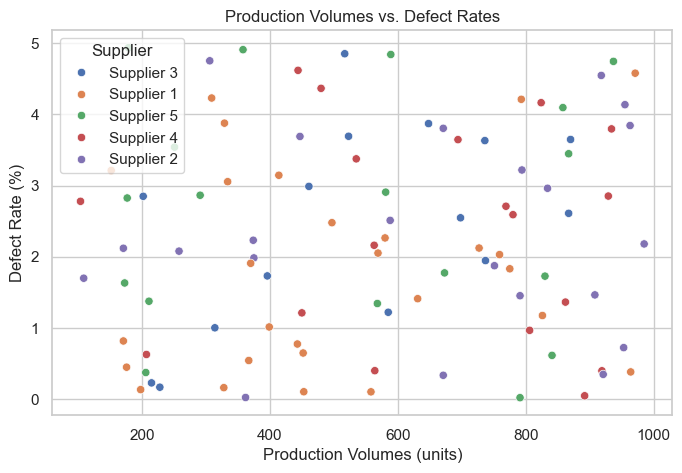

In [21]:
# Defect Rate vs. Production Volumes
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Production volumes"], y=df["Defect rates"], hue=df["Supplier name"])
plt.title("Production Volumes vs. Defect Rates")
plt.xlabel("Production Volumes (units)")
plt.ylabel("Defect Rate (%)")
plt.legend(title="Supplier")
plt.show()


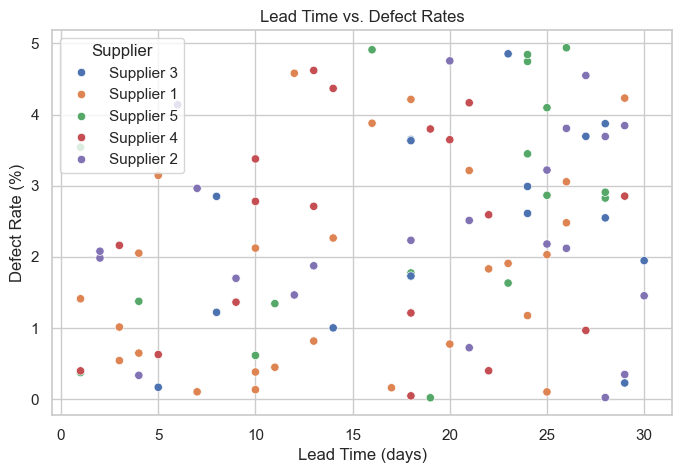

In [22]:
# Defect Rate vs. Lead Time
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Lead time"], y=df["Defect rates"], hue=df["Supplier name"])
plt.title("Lead Time vs. Defect Rates")
plt.xlabel("Lead Time (days)")
plt.ylabel("Defect Rate (%)")
plt.legend(title="Supplier")
plt.show()

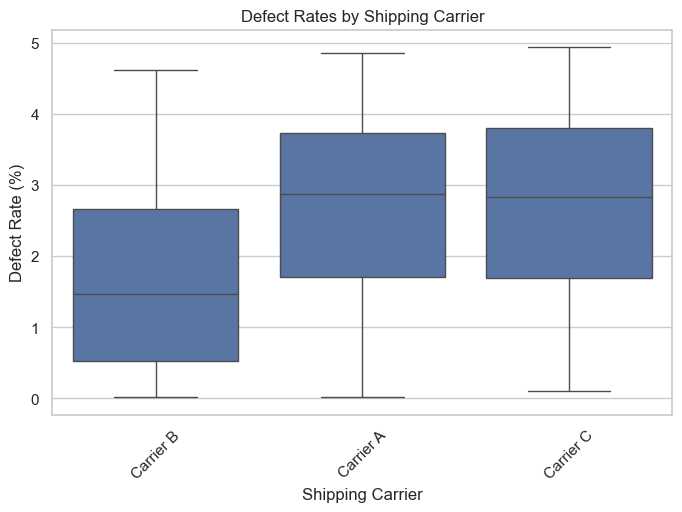

In [23]:
# Defect Rate vs. Shipping Conditions (Carriers & Routes)
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Shipping carriers"], y=df["Defect rates"])
plt.title("Defect Rates by Shipping Carrier")
plt.xlabel("Shipping Carrier")
plt.ylabel("Defect Rate (%)")
plt.xticks(rotation=45)
plt.show()

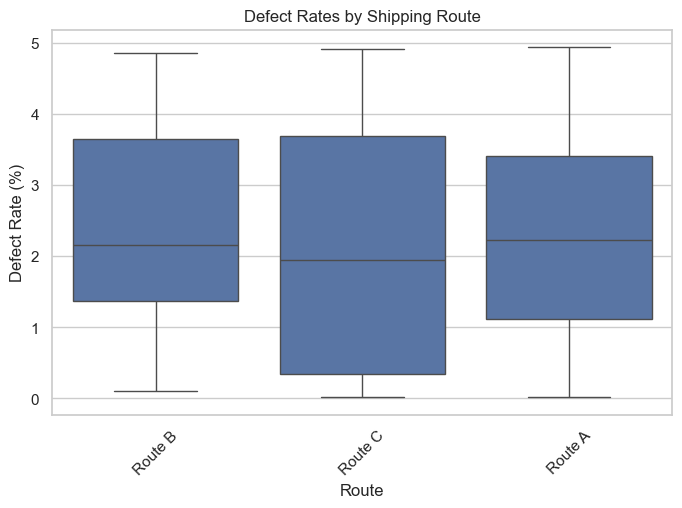

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Routes"], y=df["Defect rates"])
plt.title("Defect Rates by Shipping Route")
plt.xlabel("Route")
plt.ylabel("Defect Rate (%)")
plt.xticks(rotation=45)
plt.show()

### **Findings from the Quality Analysis**  

#### **1. Defect Rate vs. Production Volumes**
- No clear trend, but some suppliers show **higher defects at larger production volumes**.
- **Potential Action:**  
  - Focus on **quality checks for high-volume orders** to prevent mass defects.  

#### **2. Defect Rate vs. Lead Time**
- Some suppliers show **higher defects with longer lead times**, indicating potential storage or handling issues.
- **Potential Action:**  
  - Reduce **lead times** to minimize defects.  
  - Implement **better storage conditions** for products with long lead times.  

#### **3. Defect Rate vs. Shipping Conditions**
- **Certain carriers and routes have higher defect rates**, possibly due to **poor handling or transit issues**.
- **Potential Action:**  
  - Consider **switching carriers** or **optimizing routes** with lower defect rates.  
  - Implement **better packaging** for fragile shipments.  


### **Complete Summary & Conclusion: Supply Chain Quality & Cost Analysis**  

After analyzing your dataset, here are the **key insights** and **recommendations** for improving cost efficiency and product quality.  

---

### **Cost-Saving Opportunities**
1. **Shipping Costs & Transportation Modes**  
   - **Air transport is the most expensive** → Consider shifting to **Rail or Road** where feasible.  
   - Some **locations have higher shipping costs** → Optimize regional hubs and carrier contracts.  

2. **Manufacturing Costs & Defect Rates**  
   - **Higher cost does not always mean better quality** → Some **low-cost suppliers** perform better.  
   - **Supplier 5 has the worst defect rate** → Renegotiate terms or seek alternatives.  

3. **Inventory & Order Quantity Optimization**  
   - **Overstocking detected in certain product types** → Adjust inventory based on demand trends.  
   - **Longer lead times correlate with lower order quantities** → Reducing lead times could boost sales.  

---

### **Quality Issues & Trends**
1. **Supplier Performance**  
   - **Supplier 5 has the highest defect rates** (2.67%) → Needs better quality control or replacement.  
   - **Supplier 1 has the best quality** despite moderate costs → Consider shifting more production here.  

2. **Defect Rates & Production Volumes**  
   - **Some suppliers struggle with high-volume orders** → Quality checks should be stricter for large batches.  

3. **Defect Rates & Lead Time**  
   - **Longer lead times often lead to higher defects** → May be caused by poor storage conditions or material degradation.  

4. **Defect Rates & Shipping Conditions**  
   - Certain **shipping carriers and routes have higher defect rates** → Likely due to rough handling.  
   - **Potential Solution:** Switch to **reliable carriers** and improve **packaging for fragile products**.  

---

### **Actionable Recommendations**
- **Optimize shipping methods** → Reduce **air transport reliance**, negotiate with **low-cost carriers**.  
- **Supplier performance monitoring** → Address **Supplier 5’s quality issues** or seek alternatives.  
- **Inventory & demand planning** → Reduce **excess stock** and optimize **lead times**.  
- **Quality control for high-volume production** → Strengthen **QA checks** for large orders.  
- **Improve shipping & handling** → Reassess **carriers & routes** with high defect rates.  

---
